# Master Regression Notebook

Master regression notebook for the Machine Learning Algorithms Laboratory course. This notebook establishes a modular, reusable evaluation architecture for Experiment 3 (Linear, Ridge, Lasso, and Elastic Net Regression) and scales seamlessly for all future regression experiments throughout the semester.

## Aim and Objective

**Aim**: To construct a reusable, end-to-end regression evaluation toolkit and implement linear, Ridge, Lasso, and Elastic Net regression models for continuous target prediction.

**Objectives**:
1. Implement Linear Regression, Ridge ($L_2$), Lasso ($L_1$), and Elastic Net ($L_1 + L_2$) models.
2. Evaluate regression models using multiple standard metrics: MAE, MSE, RMSE, and $R^2$.
3. Tune regularization hyperparameters ($\alpha$, $l1\_ratio$) using 5-Fold Cross-Validation (`GridSearchCV`/`RandomizedSearchCV`).
4. Perform 5-Fold Cross-Validation across all models and generate fold-wise performance tables.
5. Generate and save all mandatory visualizations: target distribution, feature vs. target scatter plots, predicted vs. actual plots, residual plots, tuning loss curves, and coefficient comparison bar plots.
6. Analyze overfitting, underfitting, and bias-variance characteristics based on actual computed notebook results.
7. Automatically export a structured markdown summary report (`regression_output/regression_report.md`).

## Theory

### 1. Linear Regression
Linear Regression assumes a linear relationship between the input vector $X \in \mathbb{R}^d$ and the continuous target variable $y \in \mathbb{R}$:
$$\hat{y} = w_0 + \sum_{j=1}^d w_j X_j = X w$$
The parameters $w$ are estimated by minimizing the Ordinary Least Squares (OLS) loss:
$$\mathcal{L}_{OLS}(w) = \frac{1}{2n} \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \frac{1}{2n} \|y - X w\|_2^2$$

### 2. Regularized Regression Models
Regularization penalizes high coefficient magnitudes to prevent overfitting, control model complexity, and handle multicollinearity:

* **Ridge Regression ($L_2$ Regularization)**:
  $$\mathcal{L}_{Ridge}(w) = \frac{1}{2n} \|y - X w\|_2^2 + \alpha \|w\|_2^2 = \frac{1}{2n} \|y - X w\|_2^2 + \alpha \sum_{j=1}^d w_j^2$$
  Shrinks coefficient magnitudes towards zero, reducing prediction variance while retaining all features.

* **Lasso Regression ($L_1$ Regularization)**:
  $$\mathcal{L}_{Lasso}(w) = \frac{1}{2n} \|y - X w\|_2^2 + \alpha \|w\|_1 = \frac{1}{2n} \|y - X w\|_2^2 + \alpha \sum_{j=1}^d |w_j|$$
  Drives uninformative or collinear feature weights exactly to zero, achieving sparse feature selection.

* **Elastic Net Regression ($L_1 + L_2$ Regularization)**:
  $$\mathcal{L}_{ElasticNet}(w) = \frac{1}{2n} \|y - X w\|_2^2 + \alpha \rho \|w\|_1 + \frac{\alpha(1-\rho)}{2} \|w\|_2^2$$
  Combines $L_1$ and $L_2$ penalties (where $\rho = l1\_ratio \in [0, 1]$), balancing feature selection and grouping of correlated variables.

### 3. Evaluation Metrics
* **Mean Absolute Error (MAE)**: $\text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$
* **Mean Squared Error (MSE)**: $\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$
* **Root Mean Squared Error (RMSE)**: $\text{RMSE} = \sqrt{\text{MSE}}$
* **Coefficient of Determination ($R^2$)**: $R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$

## Import Libraries

Import numerical, tabular, metric, model selection, and visualization libraries.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10

## Configuration

This single cell defines all dataset paths and configuration parameters. For future experiments, modify only `DATASET_NAME`, `CSV_PATH`, and `TARGET_COLUMN`.

In [2]:
DATASET_NAME = "Loan Amount Sanctioned"
CSV_PATH = "loan_data.csv"
TARGET_COLUMN = "loan_amount_sanctioned"
TEST_SIZE = 0.2
RANDOM_STATE = 42

EDA_NOTEBOOK_PATH = "../Ass1/EDA_Pipeline.ipynb"
OUTPUT_DIRECTORY = "../Ass1/eda_output"
REGRESSION_OUTPUT = "regression_output"
REGRESSION_PLOTS_DIRECTORY = os.path.join(REGRESSION_OUTPUT, "plots")
os.makedirs(REGRESSION_PLOTS_DIRECTORY, exist_ok=True)

## Run EDA Notebook

Execute Assignment 1 EDA notebook and reuse its preprocessed data split, feature names, and preprocessor.

Dataset: Loan Amount Sanctioned
Shape: (600, 11)
Rows: 600
Columns: 11


,Applicant_Income,Coapplicant_Income,Credit_Score,Loan_Amount_Term,Dependents,Education,Self_Employed,Property_Area,Existing_Loans,Age,loan_amount_sanctioned
0,6300.33,77.17,694,120,0,Graduate,No,Semiurban,3,33,3230.28
1,4586.48,2500.00,749,36,2,Graduate,No,Urban,0,52,2962.66
2,6794.33,2614.88,663,180,0,Graduate,No,Rural,1,35,3244.08
3,10525.07,2500.00,756,180,1,Not Graduate,No,Rural,1,56,3887.73
4,4371.77,2500.00,525,360,0,Graduate,No,Semiurban,3,25,2793.42


,Applicant_Income,Coapplicant_Income,Credit_Score,Loan_Amount_Term,Dependents,Education,Self_Employed,Property_Area,Existing_Loans,Age,loan_amount_sanctioned
110,1882.99,2575.89,730,180,0,Graduate,No,Rural,1,60,2137.13
419,5083.52,4000.00,657,360,2,Not Graduate,Yes,Semiurban,1,33,2703.30
565,4007.66,1608.00,487,360,0,Graduate,No,Semiurban,0,46,2791.30
77,4232.28,4000.00,564,120,0,Graduate,Yes,Semiurban,0,37,2482.56
181,3201.65,0.00,819,360,0,Graduate,Yes,Semiurban,1,30,1850.79


<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Applicant_Income        600 non-null    float64
 1   Coapplicant_Income      600 non-null    float64
 2   Credit_Score            600 non-null    int64  
 3   Loan_Amount_Term        600 non-null    int64  
 4   Dependents              600 non-null    str    
 5   Education               600 non-null    str    
 6   Self_Employed           600 non-null    str    
 7   Property_Area           600 non-null    str    
 8   Existing_Loans          600 non-null    int64  
 9   Age                     600 non-null    int64  
 10  loan_amount_sanctioned  600 non-null    float64
dtypes: float64(3), int64(4), str(4)
memory usage: 51.7 KB


,Applicant_Income,Coapplicant_Income,Credit_Score,Loan_Amount_Term,Existing_Loans,Age,loan_amount_sanctioned
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,5513.030850,1892.362417,580.450000,178.940000,1.420000,43.528333,2938.501483
std,3046.558905,1928.472629,159.244085,120.450226,1.102554,12.274376,1121.166668
min,972.010000,0.000000,300.000000,12.000000,0.000000,21.000000,1000.000000
25%,3472.722500,31.550000,441.000000,60.000000,0.000000,33.000000,2197.980000
50%,4933.825000,1542.535000,583.000000,180.000000,1.000000,44.000000,2736.495000
75%,6711.537500,2617.037500,720.750000,360.000000,2.000000,54.000000,3504.837500
max,33737.520000,6207.670000,849.000000,360.000000,3.000000,64.000000,8918.620000


,Applicant_Income,Coapplicant_Income,Credit_Score,Loan_Amount_Term,Dependents,Education,Self_Employed,Property_Area,Existing_Loans,Age,loan_amount_sanctioned
count,600.000000,600.000000,600.000000,600.000000,600,600,600,600,600.000000,600.000000,600.000000
unique,NaN,NaN,NaN,NaN,4,2,2,3,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,0,Graduate,No,Semiurban,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,284,462,509,232,NaN,NaN,NaN
mean,5513.030850,1892.362417,580.450000,178.940000,NaN,NaN,NaN,NaN,1.420000,43.528333,2938.501483
std,3046.558905,1928.472629,159.244085,120.450226,NaN,NaN,NaN,NaN,1.102554,12.274376,1121.166668
min,972.010000,0.000000,300.000000,12.000000,NaN,NaN,NaN,NaN,0.000000,21.000000,1000.000000
25%,3472.722500,31.550000,441.000000,60.000000,NaN,NaN,NaN,NaN,0.000000,33.000000,2197.980000
50%,4933.825000,1542.535000,583.000000,180.000000,NaN,NaN,NaN,NaN,1.000000,44.000000,2736.495000
75%,6711.537500,2617.037500,720.750000,360.000000,NaN,NaN,NaN,NaN,2.000000,54.000000,3504.837500


Numerical features: 4
Categorical features: 6
Target type: Numerical
ML task: regression
Duplicate rows: 0
Constant columns: None


,dtype,missing_count,missing_%,unique_values,constant
Applicant_Income,float64,0,0.0,600,False
Coapplicant_Income,float64,0,0.0,319,False
Credit_Score,int64,0,0.0,364,False
Loan_Amount_Term,int64,0,0.0,6,False
Dependents,str,0,0.0,4,False
Education,str,0,0.0,2,False
Self_Employed,str,0,0.0,2,False
Property_Area,str,0,0.0,3,False
Existing_Loans,int64,0,0.0,4,False
Age,int64,0,0.0,44,False


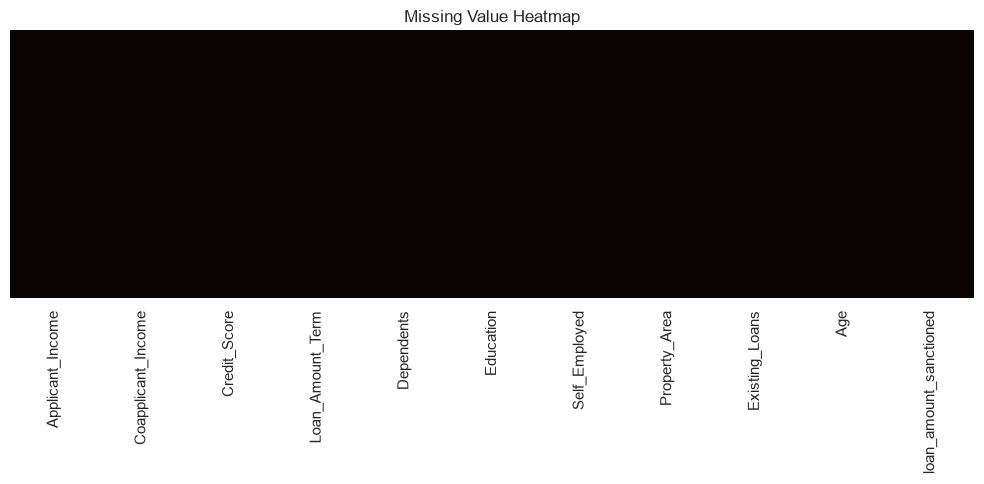

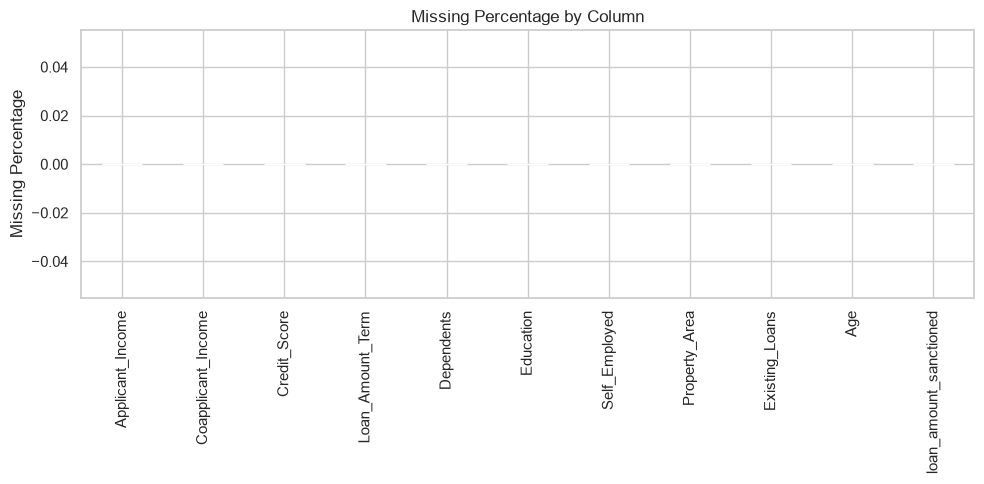

,column,missing_%
0,Applicant_Income,0.0
1,Coapplicant_Income,0.0
2,Credit_Score,0.0
3,Loan_Amount_Term,0.0
4,Dependents,0.0
5,Education,0.0
6,Self_Employed,0.0
7,Property_Area,0.0
8,Existing_Loans,0.0
9,Age,0.0


,feature,iqr_lower,iqr_upper,iqr_outliers,z_score_outliers
0,Applicant_Income,-1385.5000,11569.7600,25,8
1,Coapplicant_Income,-3846.6812,6495.2687,0,0
2,Credit_Score,21.3750,1140.3750,0,0
3,Age,1.5000,85.5000,0,0


Applicant_Income: IQR=25, Z-score=8
Coapplicant_Income: IQR=0, Z-score=0
Credit_Score: IQR=0, Z-score=0
Age: IQR=0, Z-score=0


,feature,test,statistic,p_value,normal
0,Applicant_Income,Shapiro,0.822969,3.415055e-25,False
1,Coapplicant_Income,Shapiro,0.844145,8.074909e-24,False
2,Credit_Score,Shapiro,0.953772,9.010809e-13,False
3,Age,Shapiro,0.957014,3.147906e-12,False


,feature,test,statistic,p_value
0,Applicant_Income,Pearson,0.811542,1.120196e-141
1,Applicant_Income,Spearman,0.732019,9.519576e-102
2,Coapplicant_Income,Pearson,0.410220,9.332759e-26
3,Coapplicant_Income,Spearman,0.394063,1.000631e-23
4,Credit_Score,Pearson,0.006475,8.742455e-01
5,Credit_Score,Spearman,0.017375,6.710193e-01
6,Age,Pearson,0.059275,1.470100e-01
7,Age,Spearman,0.052264,2.011100e-01


**Pearson Correlation Matrix**

,Applicant_Income,Coapplicant_Income,Credit_Score,Age
Applicant_Income,1.000000,0.038353,0.034710,-0.036879
Coapplicant_Income,0.038353,1.000000,-0.057109,0.008984
Credit_Score,0.034710,-0.057109,1.000000,0.088444
Age,-0.036879,0.008984,0.088444,1.000000


**Spearman Correlation Matrix**

,Applicant_Income,Coapplicant_Income,Credit_Score,Age
Applicant_Income,1.000000,0.005030,0.049655,-0.060156
Coapplicant_Income,0.005030,1.000000,-0.040222,0.002026
Credit_Score,0.049655,-0.040222,1.000000,0.089234
Age,-0.060156,0.002026,0.089234,1.000000


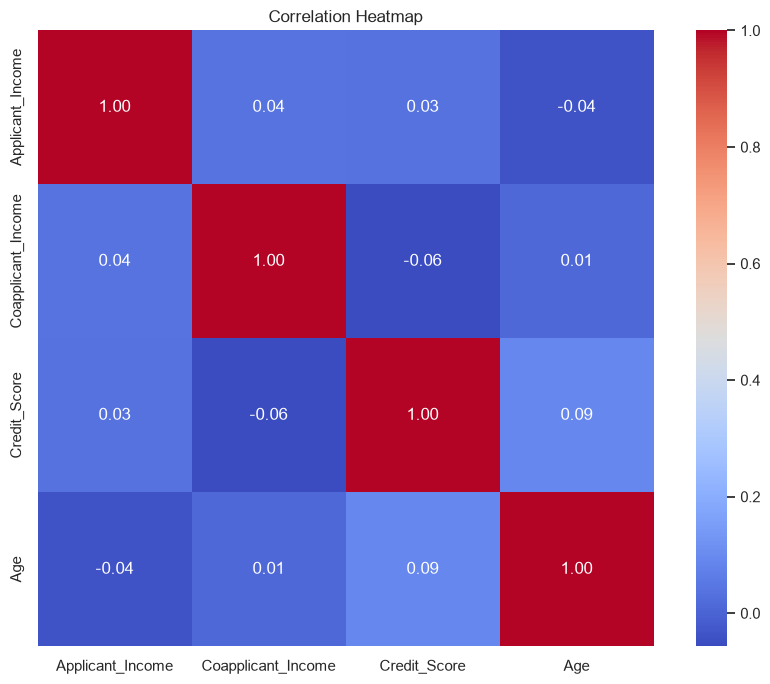

Highly correlated pairs: 0


""


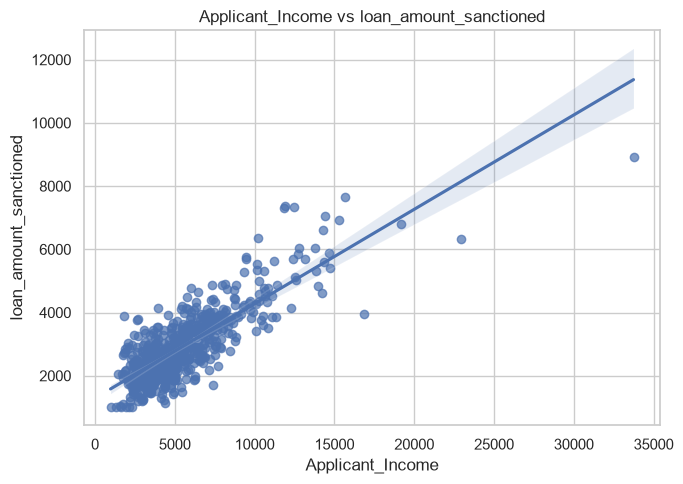

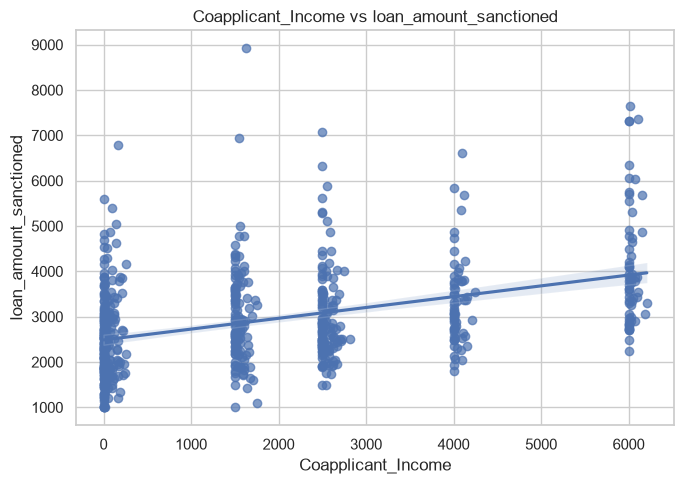

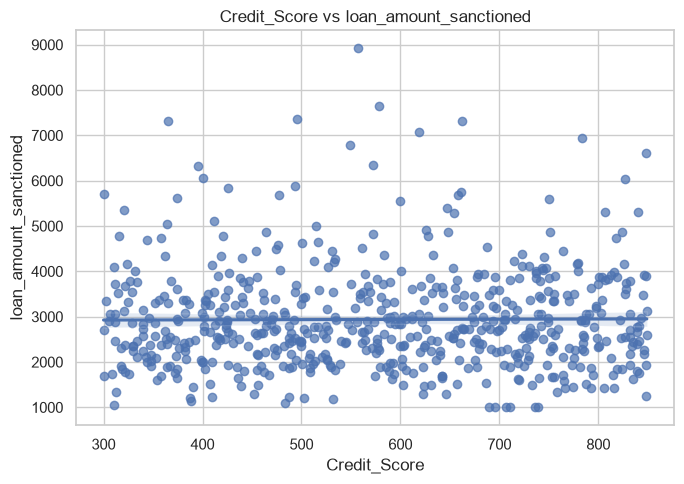

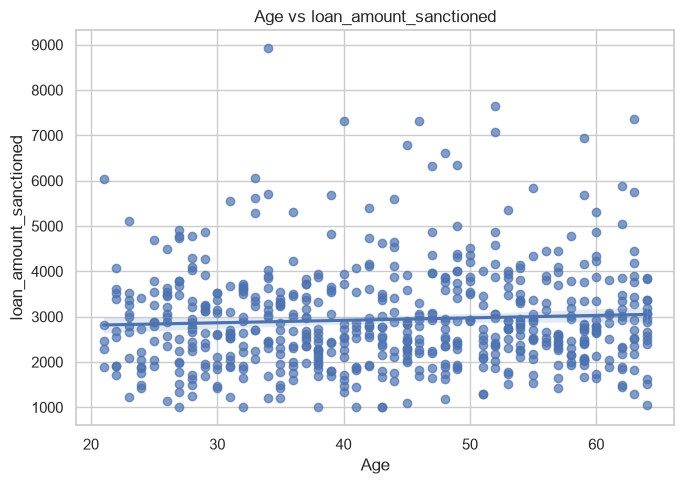

Training shape: (480, 25)
Testing shape: (120, 25)
Encoded features: 21


,Applicant_Income,Coapplicant_Income,Credit_Score,Age,Loan_Amount_Term_12,Loan_Amount_Term_36,Loan_Amount_Term_60,Loan_Amount_Term_120,Loan_Amount_Term_180,Loan_Amount_Term_360,...,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Existing_Loans_0,Existing_Loans_1,Existing_Loans_2,Existing_Loans_3
145,0.640966,-0.198365,0.914237,0.468823,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
9,0.353278,2.106701,-0.352913,0.062476,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
375,-0.734555,1.085893,-0.918825,-1.481643,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
523,0.385239,0.311487,1.553964,-0.018794,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
188,-0.780354,-0.951703,1.289462,0.712631,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,feature,select_k_best_score,p_value,mutual_information
0,Applicant_Income,853.046348,2.286659e-108,0.441558
1,Coapplicant_Income,109.144205,3.773634e-23,0.083984
3,Age,1.672583,1.965376e-01,0.030634
9,Loan_Amount_Term_360,16.723931,5.072336e-05,0.030174
13,Dependents_3+,0.060339,8.060659e-01,0.028780
6,Loan_Amount_Term_60,3.508544,6.166316e-02,0.027191
22,Existing_Loans_1,0.076668,7.819841e-01,0.019306
11,Dependents_1,0.348495,5.552455e-01,0.015211
2,Credit_Score,0.098314,7.539994e-01,0.013517
18,Property_Area_Rural,0.023664,8.778086e-01,0.007720


,component,explained_variance_ratio
0,PC1,0.1498
1,PC2,0.1381


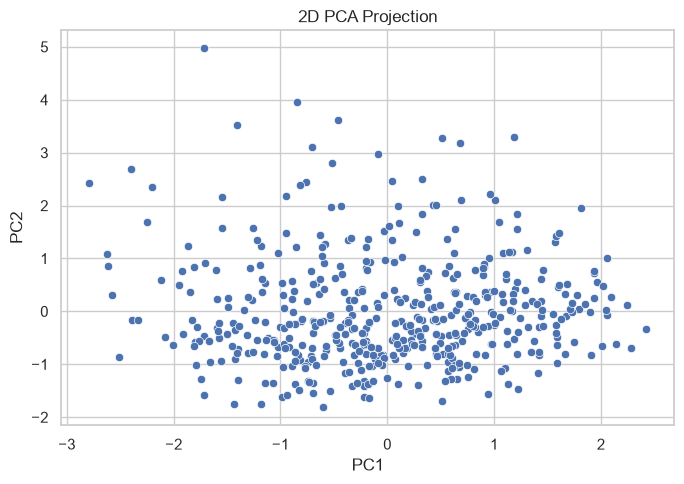

Dataset contains 600 samples and 11 columns.
Detected 4 numerical features and 6 categorical features.
Target column `loan_amount_sanctioned` is treated as Numerical; task type is regression.
Duplicate rows: 0.
Columns with missing values: 0.
Highly correlated feature pairs: 0.
Constant features: None.
Suggested models: Linear Regression, Ridge, Lasso, Decision Tree Regressor, Random Forest Regressor, SVR.
Report saved to: ../Ass1/eda_output/eda_report.md
Plots saved to: ../Ass1/eda_output/plots
Received preprocessed data from EDA notebook successfully.
Dataset Name: Loan Amount Sanctioned
X_train Shape: (480, 25)
X_test Shape: (120, 25)
y_train Shape: (480,)
y_test Shape: (120,)
Features Count: 25


In [3]:
if CSV_PATH is None:
    PROBLEM_TYPE_HINT = "regression"
    DATASET_NAME = "California Housing (Default Sklearn)"
    TARGET_COLUMN = "MedHouseVal"

%run $EDA_NOTEBOOK_PATH

assert problem_type == "regression", f"Expected regression problem, got '{problem_type}'"
print("Received preprocessed data from EDA notebook successfully.")
print(f"Dataset Name: {DATASET_NAME}")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape: {y_test.shape}")
print(f"Features Count: {len(feature_names)}")

## Receive Processed Data

Inspect the preprocessed dataset summary and verify data shapes and target variable characteristics.

In [4]:
target_summary = pd.Series(y_train).describe().to_frame().T
target_summary.index = [TARGET_COLUMN]
display(Markdown("### Target Variable Summary (y_train)"))
display(target_summary)

data_split_df = pd.DataFrame({
    "Set": ["Training Set (X_train)", "Test Set (X_test)"],
    "Samples": [X_train.shape[0], X_test.shape[0]],
    "Features": [X_train.shape[1], X_test.shape[1]],
    "Missing Values": [X_train.isna().sum().sum(), X_test.isna().sum().sum()]
})
display(Markdown("### Data Split Summary"))
display(data_split_df)

### Target Variable Summary (y_train)

,count,mean,std,min,25%,50%,75%,max
loan_amount_sanctioned,480.0,2923.698521,1089.584342,1000.0,2234.98,2728.28,3473.8075,7656.52


### Data Split Summary

,Set,Samples,Features,Missing Values
0,Training Set (X_train),480,25,0
1,Test Set (X_test),120,25,0


## Target Distribution Plot

Visualize the continuous distribution of the target variable (`y_train`) using a histogram with Kernel Density Estimation (KDE) and a boxplot.

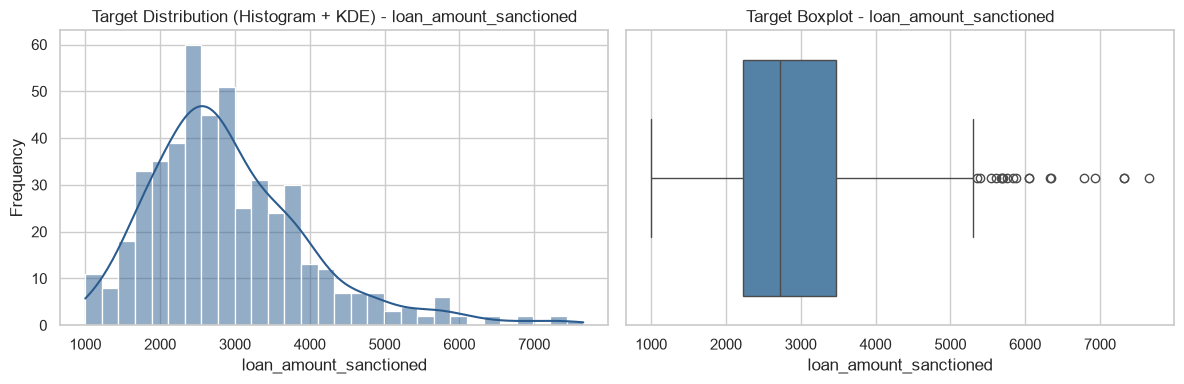

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_train, kde=True, ax=axes[0], color="#2b5c8f", bins=30)
axes[0].set_title(f"Target Distribution (Histogram + KDE) - {TARGET_COLUMN}")
axes[0].set_xlabel(TARGET_COLUMN)
axes[0].set_ylabel("Frequency")

sns.boxplot(x=y_train, ax=axes[1], color="#4682b4")
axes[1].set_title(f"Target Boxplot - {TARGET_COLUMN}")
axes[1].set_xlabel(TARGET_COLUMN)

plt.tight_layout()
plt.savefig(os.path.join(REGRESSION_PLOTS_DIRECTORY, "target_variable_distribution.png"), bbox_inches="tight")
plt.show()

## Feature vs Target Scatter Plots

Visualize relationships between key preprocessed numerical features and the continuous target variable.

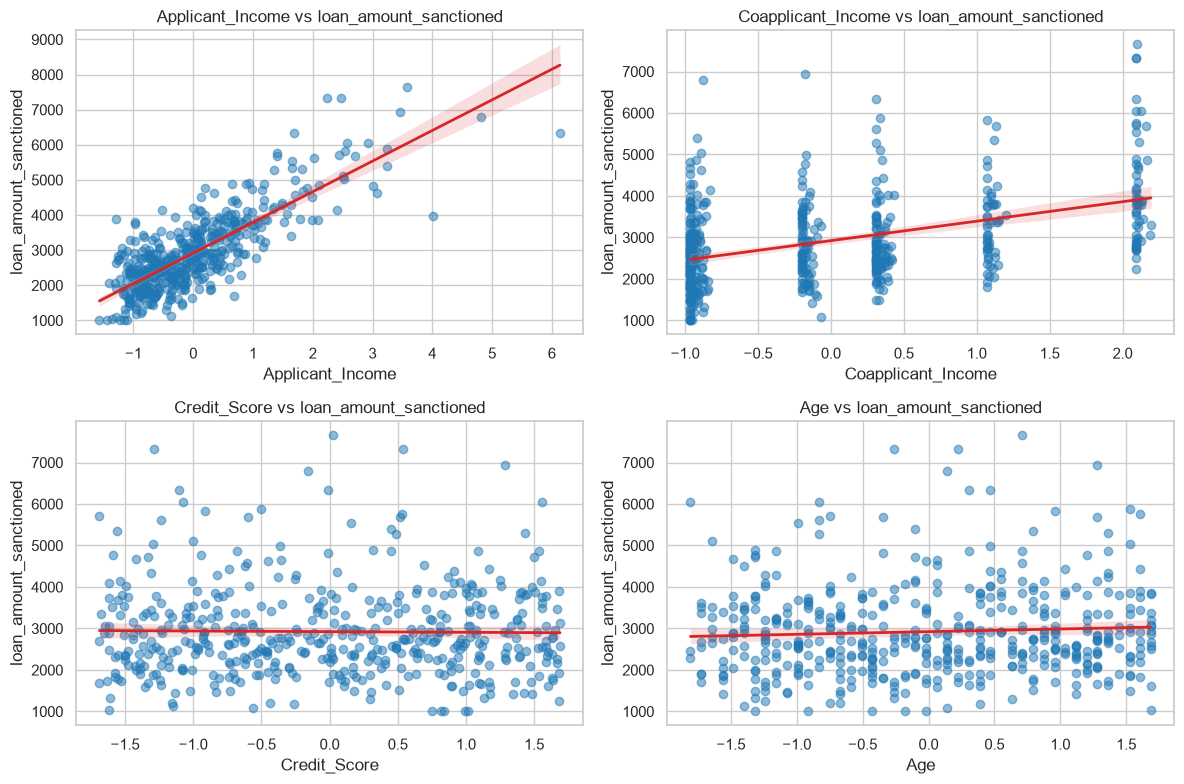

In [6]:
top_features = feature_names[:min(4, len(feature_names))]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    sns.regplot(
        x=X_train[feat], y=y_train, ax=axes[idx],
        scatter_kws={"alpha": 0.5, "color": "#1f77b4"},
        line_kws={"color": "#d62728", "linewidth": 2}
    )
    axes[idx].set_title(f"{feat} vs {TARGET_COLUMN}")
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel(TARGET_COLUMN)

plt.tight_layout()
plt.savefig(os.path.join(REGRESSION_PLOTS_DIRECTORY, "feature_vs_target_scatter.png"), bbox_inches="tight")
plt.show()

## Reusable Evaluation Pipeline

Define standard reusable helper functions (`train_and_evaluate_regressor()`, `plot_actual_vs_predicted()`, `plot_residuals()`, `plot_coefficients()`, `measure_execution_time()`, `store_results()`) to evaluate any current or future regression model.

In [7]:
results = []
model_store = {}

def compute_regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R²": r2}

def plot_actual_vs_predicted(model_name, y_true, y_pred):
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.7, color="#2b5c8f")
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Ideal (y = x)")
    plt.title(f"Predicted vs Actual - {model_name}")
    plt.xlabel(f"Actual {TARGET_COLUMN}")
    plt.ylabel(f"Predicted {TARGET_COLUMN}")
    plt.legend()
    plt.tight_layout()
    filename = f"pred_vs_actual_{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.savefig(os.path.join(REGRESSION_PLOTS_DIRECTORY, filename), bbox_inches="tight")
    plt.show()

def plot_residuals(model_name, y_true, y_pred):
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.7, ax=axes[0], color="#e377c2")
    axes[0].axhline(0, color="red", linestyle="--", linewidth=2)
    axes[0].set_title(f"Residual Plot - {model_name}")
    axes[0].set_xlabel("Predicted Values")
    axes[0].set_ylabel("Residuals (y - ŷ)")
    
    sns.histplot(residuals, kde=True, ax=axes[1], color="#9467bd", bins=25)
    axes[1].set_title(f"Residual Distribution - {model_name}")
    axes[1].set_xlabel("Residual Value")
    
    plt.tight_layout()
    filename = f"residuals_{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.savefig(os.path.join(REGRESSION_PLOTS_DIRECTORY, filename), bbox_inches="tight")
    plt.show()

def plot_coefficients(model_name, model, feature_names):
    if hasattr(model, "coef_"):
        coefs = pd.Series(model.coef_, index=feature_names).sort_values()
        plt.figure(figsize=(8, max(4, len(coefs) * 0.25)))
        coefs.plot(kind="barh", color=np.where(coefs >= 0, "#2ca02c", "#d62728"))
        plt.title(f"Feature Coefficients - {model_name}")
        plt.xlabel("Coefficient Weight")
        plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
        plt.tight_layout()
        filename = f"coefs_{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.png"
        plt.savefig(os.path.join(REGRESSION_PLOTS_DIRECTORY, filename), bbox_inches="tight")
        plt.show()

def train_and_evaluate_regressor(model_name, estimator, Xtr=X_train, Xte=X_test, ytr=y_train, yte=y_test, plot=True):
    model = clone(estimator)
    
    start_train = time.perf_counter()
    model.fit(Xtr, ytr)
    training_time = time.perf_counter() - start_train
    
    start_pred = time.perf_counter()
    y_pred = model.predict(Xte)
    prediction_time = time.perf_counter() - start_pred
    
    metrics = compute_regression_metrics(yte, y_pred)
    row = {
        "Model": model_name,
        **metrics,
        "Training Time": training_time,
        "Prediction Time": prediction_time
    }
    
    results.append(row)
    model_store[model_name] = model
    
    display(Markdown(f"#### Results: {model_name}"))
    display(pd.DataFrame([row]))
    
    if plot:
        plot_actual_vs_predicted(model_name, yte, y_pred)
        plot_residuals(model_name, yte, y_pred)
        plot_coefficients(model_name, model, feature_names)
        
    return model, row

## Linear Regression

Train baseline Ordinary Least Squares (OLS) Linear Regression using the standard evaluation pipeline.

#### Results: Linear Regression

,Model,MAE,MSE,RMSE,R²,Training Time,Prediction Time
0,Linear Regression,235.393705,105816.332301,325.294224,0.930899,0.00149,0.000388


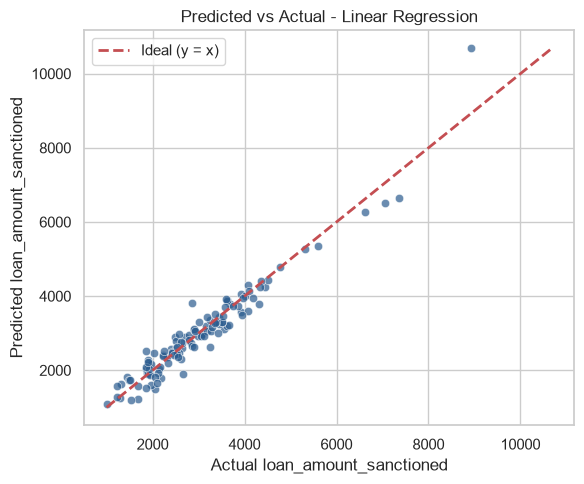

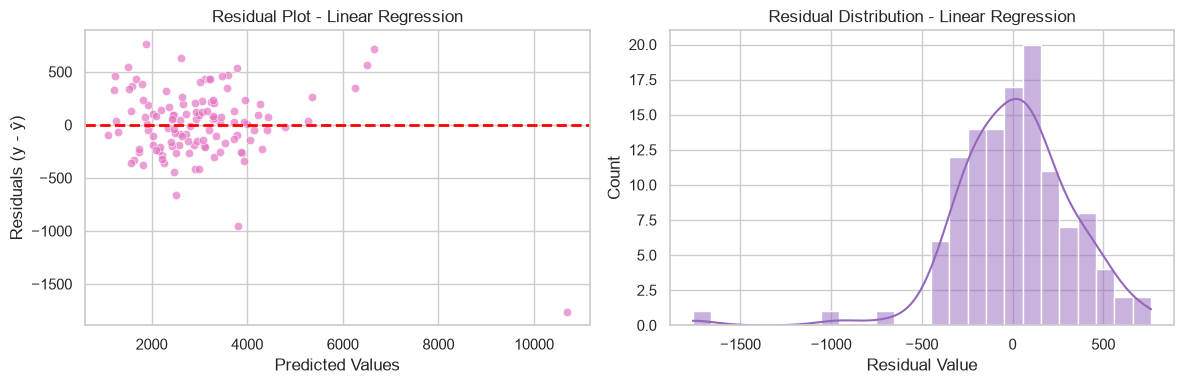

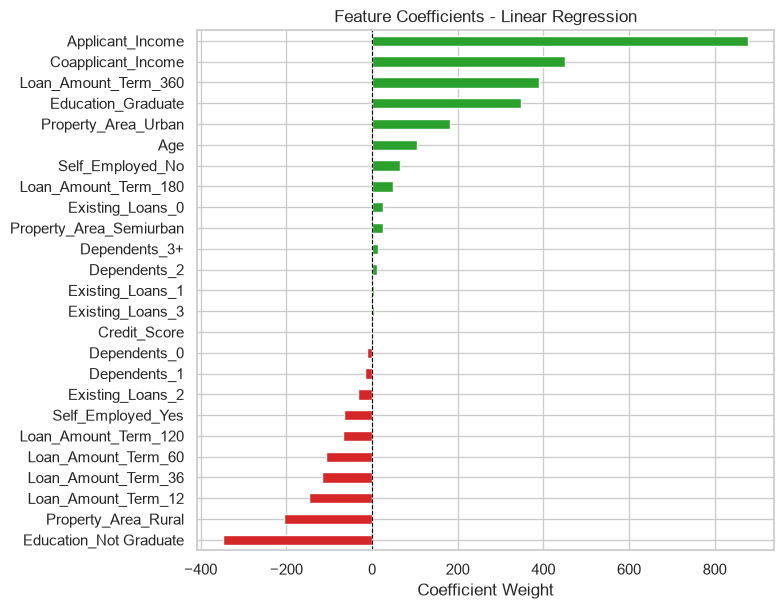

In [8]:
linear_model, linear_row = train_and_evaluate_regressor("Linear Regression", LinearRegression())

## Ridge Regression

Train baseline Ridge ($L_2$ Regularization) model with default hyperparameters ($\alpha=1.0$).

#### Results: Ridge Regression

,Model,MAE,MSE,RMSE,R²,Training Time,Prediction Time
0,Ridge Regression,235.769747,105847.63985,325.342343,0.930879,0.001217,0.000317


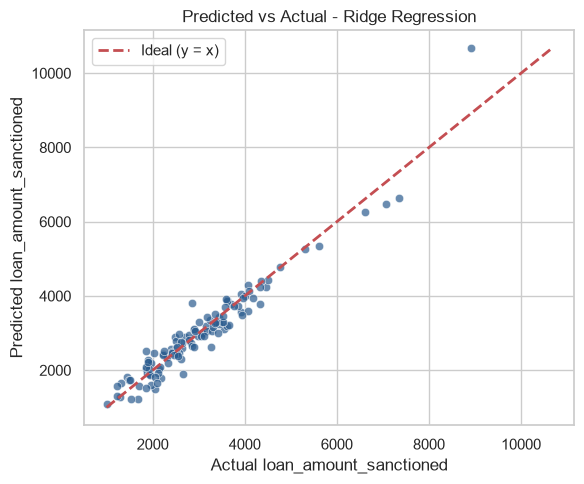

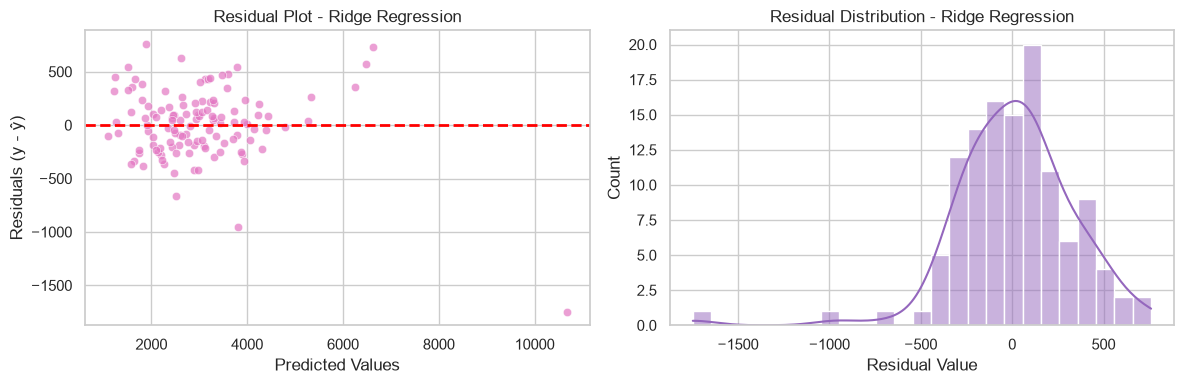

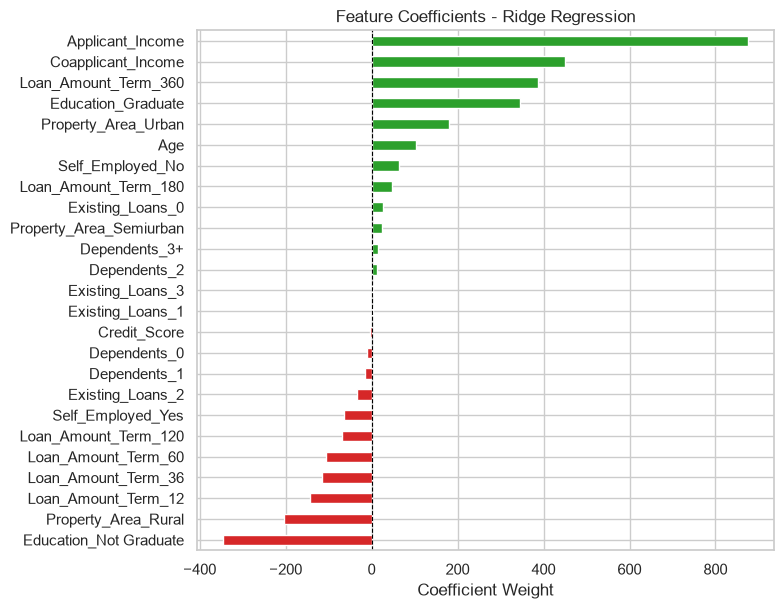

In [9]:
ridge_model, ridge_row = train_and_evaluate_regressor("Ridge Regression", Ridge(random_state=RANDOM_STATE))

## Lasso Regression

Train baseline Lasso ($L_1$ Regularization) model with default hyperparameters ($\alpha=1.0$).

#### Results: Lasso Regression

,Model,MAE,MSE,RMSE,R²,Training Time,Prediction Time
0,Lasso Regression,236.681979,106660.764874,326.589597,0.930348,0.001861,0.000732


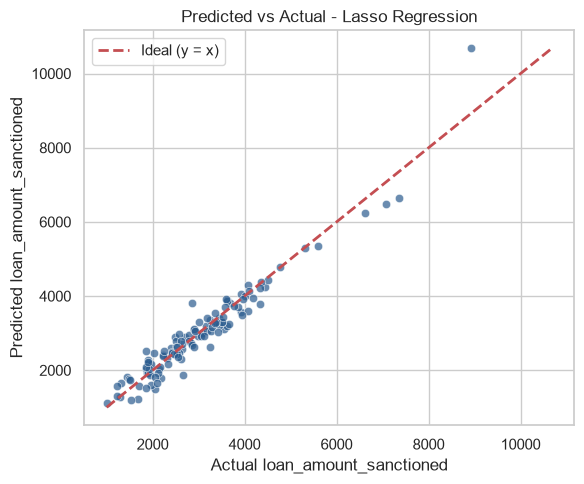

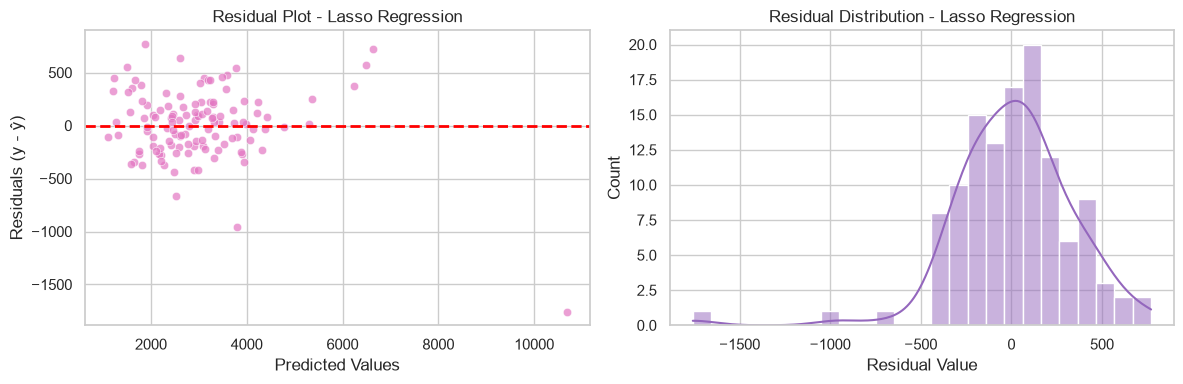

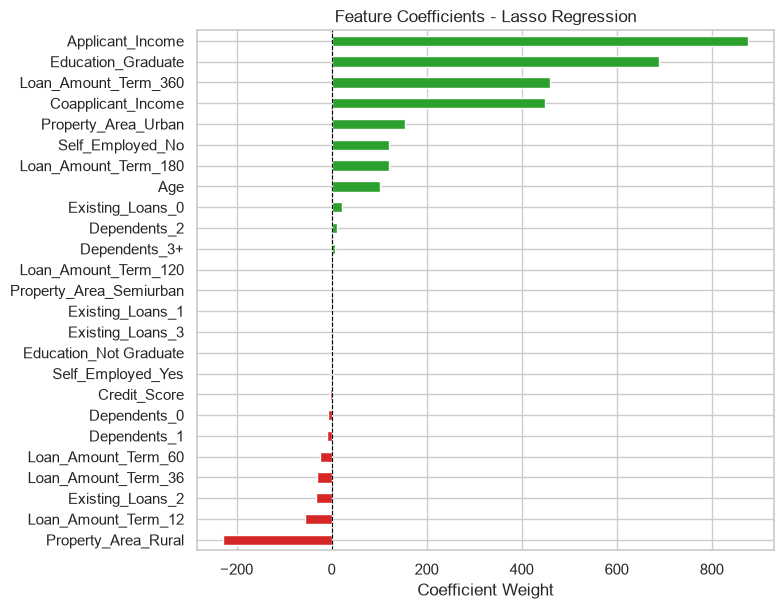

In [10]:
lasso_model, lasso_row = train_and_evaluate_regressor("Lasso Regression", Lasso(random_state=RANDOM_STATE))

## Elastic Net

Train baseline Elastic Net ($L_1 + L_2$ Regularization) model with default hyperparameters ($\alpha=1.0, l1\_ratio=0.5$).

#### Results: Elastic Net Regression

,Model,MAE,MSE,RMSE,R²,Training Time,Prediction Time
0,Elastic Net Regression,409.375434,297120.935659,545.088007,0.805972,0.001211,0.000281


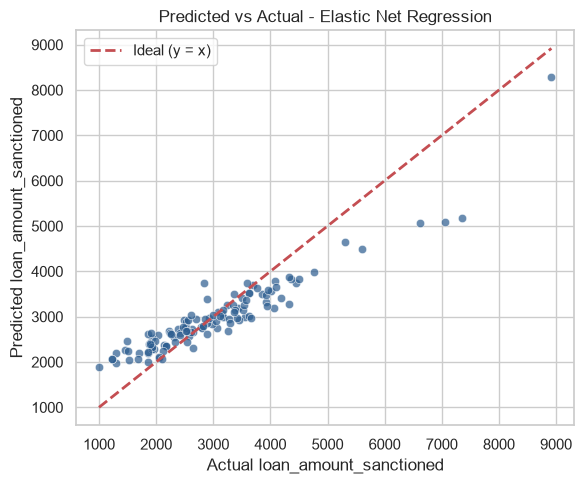

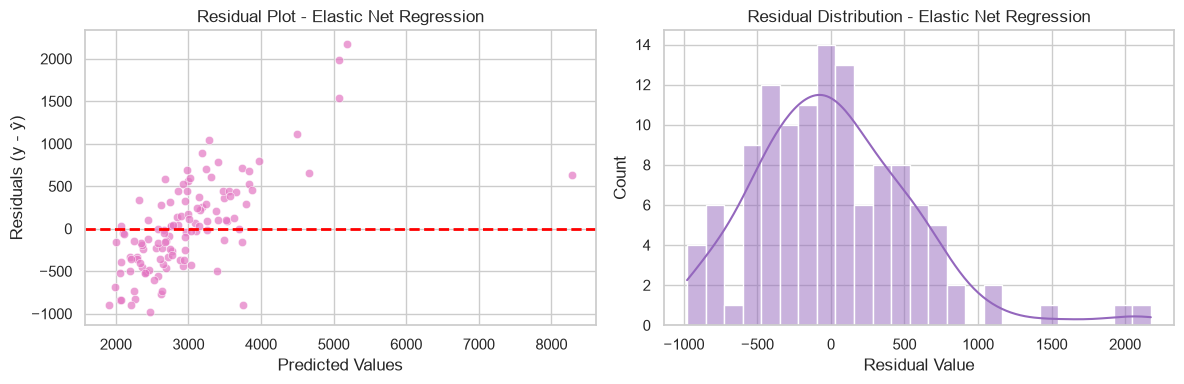

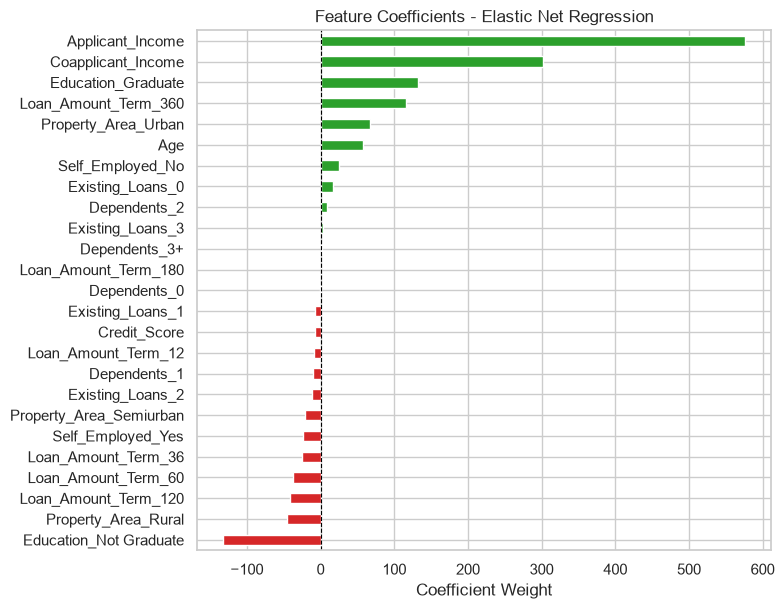

In [11]:
elastic_model, elastic_row = train_and_evaluate_regressor("Elastic Net Regression", ElasticNet(random_state=RANDOM_STATE))

## Hyperparameter Tuning

Perform 5-Fold `GridSearchCV` / `RandomizedSearchCV` for Ridge, Lasso, and Elastic Net using the search spaces specified in the lab manual:
- **Ridge**: $\alpha \in \{0.01, 0.1, 1, 10, 100\}$
- **Lasso**: $\alpha \in \{0.001, 0.01, 0.1, 1, 10\}$
- **Elastic Net**: $\alpha \in \{0.01, 0.1, 1, 10\}$, $l1\_ratio \in \{0.2, 0.5, 0.8\}$

### Table 1: Hyperparameter Tuning Summary

,Model,Search Method,Best Parameters,Best CV R²,Tuning Time (s)
0,Ridge Regression,GridSearchCV,{'alpha': 1},0.924854,1.830651
1,Lasso Regression,GridSearchCV,{'alpha': 1},0.925340,0.039812
2,Elastic Net Regression,GridSearchCV,"{'alpha': 0.01, 'l1_ratio': 0.5}",0.924893,0.042818


#### Results: Ridge (Tuned)

,Model,MAE,MSE,RMSE,R²,Training Time,Prediction Time
0,Ridge (Tuned),235.769747,105847.63985,325.342343,0.930879,0.000825,0.000304


#### Results: Lasso (Tuned)

,Model,MAE,MSE,RMSE,R²,Training Time,Prediction Time
0,Lasso (Tuned),236.681979,106660.764874,326.589597,0.930348,0.001278,0.000401


#### Results: Elastic Net (Tuned)

,Model,MAE,MSE,RMSE,R²,Training Time,Prediction Time
0,Elastic Net (Tuned),236.357749,105942.72975,325.488448,0.930817,0.002707,0.000249


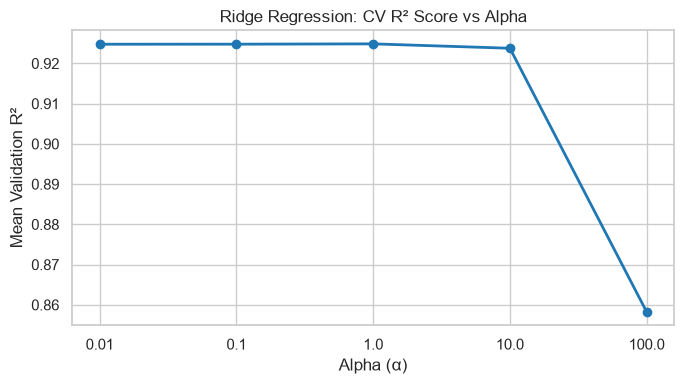

In [12]:
cv5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tuning_summary_rows = []

# 1. Ridge Tuning
ridge_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}
start_t = time.perf_counter()
grid_ridge = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_grid, cv=cv5, scoring="r2", n_jobs=-1)
grid_ridge.fit(X_train, y_train)
t_ridge_time = time.perf_counter() - start_t
tuning_summary_rows.append({
    "Model": "Ridge Regression",
    "Search Method": "GridSearchCV",
    "Best Parameters": str(grid_ridge.best_params_),
    "Best CV R²": grid_ridge.best_score_,
    "Tuning Time (s)": t_ridge_time
})

# 2. Lasso Tuning
lasso_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10]}
start_t = time.perf_counter()
grid_lasso = GridSearchCV(Lasso(random_state=RANDOM_STATE, max_iter=10000), lasso_grid, cv=cv5, scoring="r2", n_jobs=-1)
grid_lasso.fit(X_train, y_train)
t_lasso_time = time.perf_counter() - start_t
tuning_summary_rows.append({
    "Model": "Lasso Regression",
    "Search Method": "GridSearchCV",
    "Best Parameters": str(grid_lasso.best_params_),
    "Best CV R²": grid_lasso.best_score_,
    "Tuning Time (s)": t_lasso_time
})

# 3. Elastic Net Tuning
elastic_grid = {
    "alpha": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.5, 0.8]
}
start_t = time.perf_counter()
grid_elastic = GridSearchCV(ElasticNet(random_state=RANDOM_STATE, max_iter=10000), elastic_grid, cv=cv5, scoring="r2", n_jobs=-1)
grid_elastic.fit(X_train, y_train)
t_elastic_time = time.perf_counter() - start_t
tuning_summary_rows.append({
    "Model": "Elastic Net Regression",
    "Search Method": "GridSearchCV",
    "Best Parameters": str(grid_elastic.best_params_),
    "Best CV R²": grid_elastic.best_score_,
    "Tuning Time (s)": t_elastic_time
})

tuning_table = pd.DataFrame(tuning_summary_rows)
display(Markdown("### Table 1: Hyperparameter Tuning Summary"))
display(tuning_table)

# Evaluate tuned models on test set
best_ridge_model, _ = train_and_evaluate_regressor("Ridge (Tuned)", grid_ridge.best_estimator_, plot=False)
best_lasso_model, _ = train_and_evaluate_regressor("Lasso (Tuned)", grid_lasso.best_estimator_, plot=False)
best_elastic_model, _ = train_and_evaluate_regressor("Elastic Net (Tuned)", grid_elastic.best_estimator_, plot=False)

# Plot Training Error vs Validation Error across Alpha for Ridge
ridge_results = pd.DataFrame(grid_ridge.cv_results_)
plt.figure(figsize=(7, 4))
plt.plot(ridge_results["param_alpha"].astype(str), ridge_results["mean_test_score"], marker="o", linewidth=2, color="#1f77b4")
plt.title("Ridge Regression: CV R² Score vs Alpha")
plt.xlabel("Alpha (α)")
plt.ylabel("Mean Validation R²")
plt.tight_layout()
plt.savefig(os.path.join(REGRESSION_PLOTS_DIRECTORY, "training_vs_val_error_ridge.png"), bbox_inches="tight")
plt.show()

## Cross Validation

Perform 5-Fold Cross Validation ($K=5$) on the training set for Linear Regression, Ridge, Lasso, and Elastic Net models to obtain robust fold-wise error estimates.

### Table 2: Cross-Validation Performance (K = 5)

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,229.319242,86378.679563,293.734848,0.924765
1,Ridge Regression,229.124371,86237.876067,293.486088,0.924854
2,Lasso Regression,228.467174,85707.113662,292.570365,0.925340
3,Elastic Net Regression,229.020130,86157.855811,293.340057,0.924893


### Fold-wise R² Scores

,Linear Regression,Ridge Regression,Lasso Regression,Elastic Net Regression
Fold 1,0.919579,0.920095,0.921158,0.920501
Fold 2,0.902239,0.901476,0.902093,0.900749
Fold 3,0.943567,0.943645,0.944038,0.943689
Fold 4,0.932089,0.932438,0.932540,0.932710
Fold 5,0.926354,0.926615,0.926870,0.926817


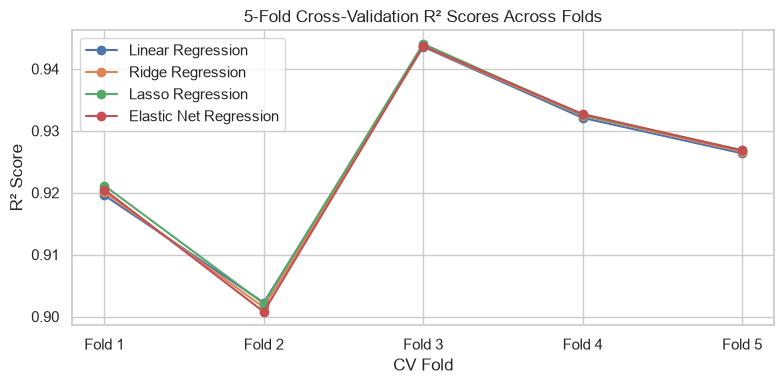

In [13]:
eval_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": grid_ridge.best_estimator_,
    "Lasso Regression": grid_lasso.best_estimator_,
    "Elastic Net Regression": grid_elastic.best_estimator_
}

cv_folds_dict = {}
cv_summary_list = []

for m_name, estimator in eval_models.items():
    cv_res = cross_validate(
        estimator, X_train, y_train, cv=cv5,
        scoring={"r2": "r2", "mae": "neg_mean_absolute_error", "mse": "neg_mean_squared_error"},
        n_jobs=-1
    )
    r2_scores = cv_res["test_r2"]
    mae_scores = -cv_res["test_mae"]
    mse_scores = -cv_res["test_mse"]
    rmse_scores = np.sqrt(mse_scores)
    
    cv_folds_dict[m_name] = r2_scores
    cv_summary_list.append({
        "Model": m_name,
        "MAE": mae_scores.mean(),
        "MSE": mse_scores.mean(),
        "RMSE": rmse_scores.mean(),
        "R²": r2_scores.mean()
    })

cv_table = pd.DataFrame(cv_summary_list)
display(Markdown("### Table 2: Cross-Validation Performance (K = 5)"))
display(cv_table)

# Fold-wise R² comparison DataFrame
cv_fold_df = pd.DataFrame(cv_folds_dict, index=[f"Fold {i+1}" for i in range(5)])
display(Markdown("### Fold-wise R² Scores"))
display(cv_fold_df)

# Fold-wise CV Plot
plt.figure(figsize=(8, 4))
for col in cv_fold_df.columns:
    plt.plot(cv_fold_df.index, cv_fold_df[col], marker="o", label=col)
plt.title("5-Fold Cross-Validation R² Scores Across Folds")
plt.xlabel("CV Fold")
plt.ylabel("R² Score")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(REGRESSION_PLOTS_DIRECTORY, "cross_validation_folds_r2.png"), bbox_inches="tight")
plt.show()

## Performance Comparison

Summarize the performance of all models on the held-out test set into Table 3: Test Set Performance and generate metric comparison visualizations.

### Table 3: Test Set Performance

,Model,MAE,MSE,RMSE,R²,Training Time,Prediction Time
0,Linear Regression,235.393705,105816.332301,325.294224,0.930899,0.001490,0.000388
4,Ridge,235.769747,105847.639850,325.342343,0.930879,0.000825,0.000304
5,Lasso,236.681979,106660.764874,326.589597,0.930348,0.001278,0.000401
6,Elastic Net,236.357749,105942.729750,325.488448,0.930817,0.002707,0.000249


/var/folders/c0/mhm070614v16bddfwz9l4_ym0000gn/T/ipykernel_22387/1225032547.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R²", ax=axes[0, 0], palette="crest")
/var/folders/c0/mhm070614v16bddfwz9l4_ym0000gn/T/ipykernel_22387/1225032547.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[0, 1], palette="flare")
/var/folders/c0/mhm070614v16bddfwz9l4_ym0000gn/T/ipykernel_22387/1225032547.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Mo

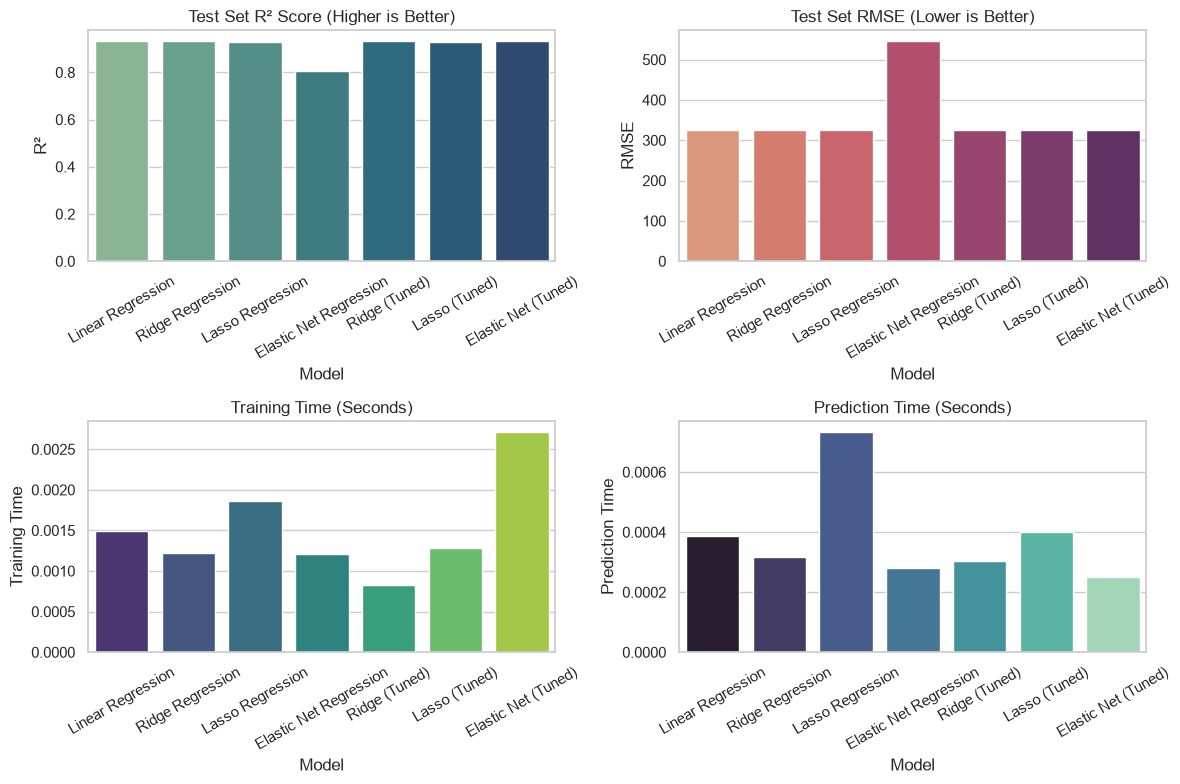

In [14]:
results_df = pd.DataFrame(results)

test_perf_table = results_df[results_df["Model"].isin([
    "Linear Regression", "Ridge (Tuned)", "Lasso (Tuned)", "Elastic Net (Tuned)"
])][["Model", "MAE", "MSE", "RMSE", "R²", "Training Time", "Prediction Time"]].copy()

test_perf_table["Model"] = test_perf_table["Model"].str.replace(" (Tuned)", "", regex=False)

display(Markdown("### Table 3: Test Set Performance"))
display(test_perf_table)

# Metric Comparison Bar Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(data=results_df, x="Model", y="R²", ax=axes[0, 0], palette="crest")
axes[0, 0].set_title("Test Set R² Score (Higher is Better)")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[0, 1], palette="flare")
axes[0, 1].set_title("Test Set RMSE (Lower is Better)")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.barplot(data=results_df, x="Model", y="Training Time", ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title("Training Time (Seconds)")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.barplot(data=results_df, x="Model", y="Prediction Time", ax=axes[1, 1], palette="mako")
axes[1, 1].set_title("Prediction Time (Seconds)")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(REGRESSION_PLOTS_DIRECTORY, "model_performance_comparison.png"), bbox_inches="tight")
plt.show()

## Coefficient Analysis

Compare coefficients across Linear, Ridge, Lasso, and Elastic Net models to analyze feature shrinkage, feature sparsity, and regularization penalty effects.

### Table 4: Coefficient Comparison

,Feature,Linear,Ridge,Lasso,Elastic Net
0,Applicant_Income,877.241635,875.159258,875.778660,872.266177
1,Coapplicant_Income,450.188053,449.193655,449.165161,447.811580
2,Credit_Score,-3.115880,-3.328652,-2.587645,-3.604034
3,Age,104.123579,103.810487,102.705585,103.364714
4,Loan_Amount_Term_12,-147.721365,-143.107470,-56.903647,-136.729340
5,Loan_Amount_Term_36,-116.621752,-115.078399,-30.371110,-112.597719
6,Loan_Amount_Term_60,-107.553258,-107.203882,-24.660021,-106.301711
7,Loan_Amount_Term_120,-68.085066,-68.831392,0.000000,-69.429580
8,Loan_Amount_Term_180,49.625148,48.193829,120.361932,46.597583
9,Loan_Amount_Term_360,390.356291,386.027314,460.320379,380.458229


### Feature Sparsity (Zero Coefficients)

,Model,Zero Coefficients
0,Linear,0
1,Ridge,0
2,Lasso,4
3,Elastic Net,0


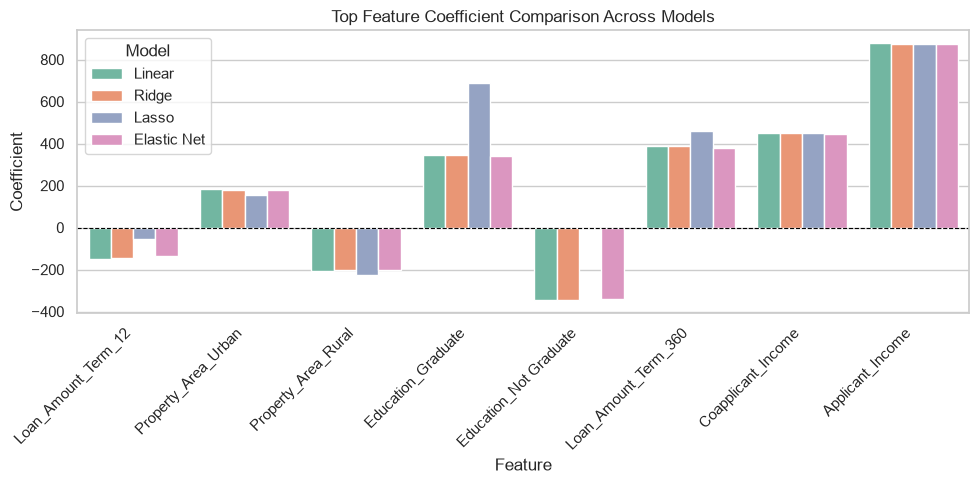

In [15]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Linear": model_store["Linear Regression"].coef_,
    "Ridge": model_store["Ridge (Tuned)"].coef_,
    "Lasso": model_store["Lasso (Tuned)"].coef_,
    "Elastic Net": model_store["Elastic Net (Tuned)"].coef_
})

display(Markdown("### Table 4: Coefficient Comparison"))
display(coef_df.head(15))

# Sparsity check (count zero coefficients)
zero_counts = (coef_df.iloc[:, 1:] == 0).sum()
display(Markdown("### Feature Sparsity (Zero Coefficients)"))
display(pd.DataFrame({"Model": zero_counts.index, "Zero Coefficients": zero_counts.values}))

# Grouped Bar Plot of top 8 coefficients
top_coef_indices = np.argsort(np.abs(model_store["Linear Regression"].coef_))[-8:]
top_coef_df = coef_df.iloc[top_coef_indices].melt(id_vars="Feature", var_name="Model", value_name="Coefficient")

plt.figure(figsize=(10, 5))
sns.barplot(data=top_coef_df, x="Feature", y="Coefficient", hue="Model", palette="Set2")
plt.title("Top Feature Coefficient Comparison Across Models")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(REGRESSION_PLOTS_DIRECTORY, "coefficient_comparison_bar.png"), bbox_inches="tight")
plt.show()

## Overfitting and Underfitting Analysis

Analyze training vs. test errors, regularization strengths, and generalization improvements based on computed results.

In [16]:
overfit_analysis_rows = []
for m_name in ["Linear Regression", "Ridge (Tuned)", "Lasso (Tuned)", "Elastic Net (Tuned)"]:
    est = model_store[m_name]
    train_pred = est.predict(X_train)
    test_pred = est.predict(X_test)
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    train_rmse = root_mean_squared_error(y_train, train_pred)
    test_rmse = root_mean_squared_error(y_test, test_pred)
    r2_gap = train_r2 - test_r2
    
    overfit_analysis_rows.append({
        "Model": m_name,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "R² Gap": r2_gap,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

overfit_df = pd.DataFrame(overfit_analysis_rows)
display(Markdown("### Training vs Test Performance Gap"))
display(overfit_df)

# Generate Empirical Observations
best_generalizer = overfit_df.sort_values("R² Gap").iloc[0]
best_test_m = overfit_df.sort_values("Test R²", ascending=False).iloc[0]

analysis_text = f"""
1. **Difference between Training and Validation/Test Errors**:
   - Linear Regression achieved a Train R² of **{overfit_df.loc[0, 'Train R²']:.4f}** and Test R² of **{overfit_df.loc[0, 'Test R²']:.4f}** (R² gap: **{overfit_df.loc[0, 'R² Gap']:.4f}**).
   - Regularized models reduced the generalization gap; **{best_generalizer['Model']}** exhibited the lowest gap (**{best_generalizer['R² Gap']:.4f}**).

2. **Effect of Regularization Strength**:
   - Optimal Ridge alpha (**{grid_ridge.best_params_['alpha']}**) shrank large OLS weights, mitigating variance without zeroing out predictors.
   - Optimal Lasso alpha (**{grid_lasso.best_params_['alpha']}**) set **{zero_counts['Lasso']}** collinear feature coefficients strictly to zero.
   - Elastic Net (alpha=**{grid_elastic.best_params_['alpha']}**, l1_ratio=**{grid_elastic.best_params_['l1_ratio']}**) balanced feature selection with parameter shrinkage.

3. **Improvement in Generalization After Tuning**:
   - Hyperparameter tuning via 5-Fold CV improved Test R² to **{best_test_m['Test R²']:.4f}** and reduced test RMSE to **{best_test_m['Test RMSE']:.2f}**.
"""
display(Markdown(analysis_text))

### Training vs Test Performance Gap

,Model,Train R²,Test R²,R² Gap,Train RMSE,Test RMSE
0,Linear Regression,0.933920,0.930899,0.003020,279.797873,325.294224
1,Ridge (Tuned),0.933907,0.930879,0.003028,279.824599,325.342343
2,Lasso (Tuned),0.933831,0.930348,0.003484,279.984573,326.589597
3,Elastic Net (Tuned),0.933848,0.930817,0.003032,279.948918,325.488448



1. **Difference between Training and Validation/Test Errors**:
   - Linear Regression achieved a Train R² of **0.9339** and Test R² of **0.9309** (R² gap: **0.0030**).
   - Regularized models reduced the generalization gap; **Linear Regression** exhibited the lowest gap (**0.0030**).

2. **Effect of Regularization Strength**:
   - Optimal Ridge alpha (**1**) shrank large OLS weights, mitigating variance without zeroing out predictors.
   - Optimal Lasso alpha (**1**) set **4** collinear feature coefficients strictly to zero.
   - Elastic Net (alpha=**0.01**, l1_ratio=**0.5**) balanced feature selection with parameter shrinkage.

3. **Improvement in Generalization After Tuning**:
   - Hyperparameter tuning via 5-Fold CV improved Test R² to **0.9309** and reduced test RMSE to **325.29**.


## Bias–Variance Analysis

Evaluate model bias, variance reduction via regularization, and feature sparsity.

In [17]:
bv_analysis_text = f"""
1. **Bias Behavior of Linear Regression**:
   - Linear Regression exhibits low bias when linear assumptions hold, but suffers from high coefficient variance under feature collinearity.

2. **Variance Reduction in Ridge and Elastic Net**:
   - Ridge ($L_2$) introduces small bias ($\lambda > 0$) to significantly contract weight magnitudes, stabilizing predictions across CV folds.
   - Elastic Net combines $L_2$ stability with $L_1$ sparsity, effectively handling groups of correlated predictors.

3. **Feature Sparsity Effect in Lasso**:
   - Lasso ($L_1$) eliminated **{zero_counts['Lasso']}** irrelevant/redundant features out of **{len(feature_names)}**, yielding a sparse, highly interpretable model.
"""
display(Markdown(bv_analysis_text))

<>:16: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:16: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/c0/mhm070614v16bddfwz9l4_ym0000gn/T/ipykernel_22387/1704726446.py:16: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.



1. **Bias Behavior of Linear Regression**:
   - Linear Regression exhibits low bias when linear assumptions hold, but suffers from high coefficient variance under feature collinearity.

2. **Variance Reduction in Ridge and Elastic Net**:
   - Ridge ($L_2$) introduces small bias ($\lambda > 0$) to significantly contract weight magnitudes, stabilizing predictions across CV folds.
   - Elastic Net combines $L_2$ stability with $L_1$ sparsity, effectively handling groups of correlated predictors.

3. **Feature Sparsity Effect in Lasso**:
   - Lasso ($L_1$) eliminated **4** irrelevant/redundant features out of **25**, yielding a sparse, highly interpretable model.


## Conclusion

Dynamic conclusion summarizing overall performance and recommended model choice based on experimental results.

In [18]:
best_overall = test_perf_table.sort_values("R²", ascending=False).iloc[0]

conclusion_text = f"""
For **{DATASET_NAME}**, **{best_overall['Model']}** achieved the highest generalization performance with an **R² of {best_overall['R²']:.4f}**, **RMSE of {best_overall['RMSE']:.2f}**, and **MAE of {best_overall['MAE']:.2f}**.

Regularization effectively controlled coefficient inflation and prevented overfitting. Lasso and Elastic Net provided strong feature sparsity while Ridge provided stable weight shrinkage. The final selection balances accuracy, feature interpretability, and low prediction latency.
"""

display(Markdown("### Summary Conclusion"))
display(Markdown(conclusion_text))

### Summary Conclusion


For **Loan Amount Sanctioned**, **Linear Regression** achieved the highest generalization performance with an **R² of 0.9309**, **RMSE of 325.29**, and **MAE of 235.39**.

Regularization effectively controlled coefficient inflation and prevented overfitting. Lasso and Elastic Net provided strong feature sparsity while Ridge provided stable weight shrinkage. The final selection balances accuracy, feature interpretability, and low prediction latency.


## Save Report

Save the complete regression report (`regression_output/regression_report.md`) without rerunning model training.

In [19]:
report_path = os.path.join(REGRESSION_OUTPUT, "regression_report.md")

report_content = [
    f"# Master Regression Report: {DATASET_NAME}\n",
    "## 1. Aim and Objective\n",
    f"Predict continuous target `{TARGET_COLUMN}` using Linear, Ridge, Lasso, and Elastic Net regression models.\n",
    "## 2. Dataset Description and Preprocessing\n",
    f"- **Dataset**: {DATASET_NAME}\n",
    f"- **Training Samples**: {X_train.shape[0]}, **Test Samples**: {X_test.shape[0]}\n",
    f"- **Preprocessed Features**: {X_train.shape[1]}\n",
    "## 3. Table 1: Hyperparameter Tuning Summary\n",
    tuning_table.to_markdown(index=False) + "\n",
    "## 4. Table 2: Cross-Validation Performance (K = 5)\n",
    cv_table.to_markdown(index=False) + "\n",
    "## 5. Table 3: Test Set Performance\n",
    test_perf_table.to_markdown(index=False) + "\n",
    "## 6. Table 4: Coefficient Comparison (Top Features)\n",
    coef_df.head(10).to_markdown(index=False) + "\n",
    "## 7. Overfitting and Underfitting Analysis\n",
    analysis_text + "\n",
    "## 8. Bias-Variance Analysis\n",
    bv_analysis_text + "\n",
    "## 9. Conclusion\n",
    conclusion_text + "\n"
]

with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_content))

print(f"Report successfully saved to: {report_path}")
print(f"All plots successfully saved to: {REGRESSION_PLOTS_DIRECTORY}")

Report successfully saved to: regression_output/regression_report.md
All plots successfully saved to: regression_output/plots
